# Supporting 2 - The simulator and its verification

*Optional detail; start with `notebooks/00_START_HERE.ipynb`.*

Layered radial CO2-brine IMPES model (`impes.py`, from `3-IMPES.pdf`). This notebook (i) runs the two-layer case that exposed the old well coupling, (ii) reproduces the Buckley-Leverett benchmark, and (iii) reads the full verification report written by the pipeline.

In [1]:
import sys, json, time
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
from subsurfaceml.config import load_config

CONFIG = 'demo'                 # which completed run this notebook reads
cfg = load_config(ROOT / 'config' / f'{CONFIG}.yaml')
S = json.loads((Path(cfg.paths.metrics) / 'summary.json').read_text())
pd.set_option('display.max_colwidth', 80)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3,
                     'font.size': 9, 'figure.constrained_layout.use': True})


def provenance(kind, what):
    """Label every result: read from a finished run, or computed right here."""
    label = {'loaded': 'LOADED from the completed ' + CONFIG + ' run',
             'computed': 'COMPUTED NOW in this notebook session'}[kind]
    print(f'[{label}]  {what}')
from subsurfaceml.grid import RadialGrid, CartesianGrid1D
from subsurfaceml.impes import TwoPhaseModel, InjectionSchedule
from subsurfaceml.fluids import FluidProperties, RelPerm, RockProperties, bl_profile_1d, welge_shock
from subsurfaceml.units import md_to_m2, MPA, YEAR, DAY

## 1. One injector, two unequal layers, one bottom-hole pressure

500 mD / porosity 0.25 against 20 mD / porosity 0.08 in a sealed compartment. The well equation `q_l = J_l (p_bh - p_l0)` with `sum q_l = Q` is solved together with the pressure field.

max spread of implied BHP between layers [Pa]: 0.0
max relative error of the total rate: 2.0036056147532122e-14
CO2 mass-balance error: 6.044023096853007e-15


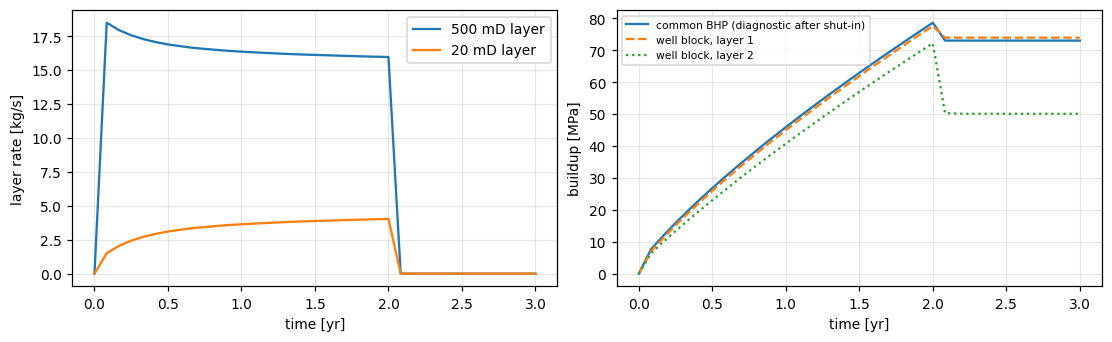

In [2]:
n = 30
grids = [RadialGrid(n=n, r_w=0.15, r_e=1500, h=10, r_near=5) for _ in range(2)]
k = np.stack([np.full(n, md_to_m2(500)), np.full(n, md_to_m2(20))])
phi = np.stack([np.full(n, .25), np.full(n, .08)])
m = TwoPhaseModel(grids, k, phi, FluidProperties(), RelPerm(), RockProperties(), 15*MPA,
                  outer_bc='closed', dt_max=30*DAY)
t = np.linspace(0, 3*YEAR, 37)
res = m.run(InjectionSchedule([0, 2*YEAR, 3*YEAR], [20.0, 0.0]), t)
print('max spread of implied BHP between layers [Pa]:', res.diagnostics['max_bhp_spread_Pa'])
print('max relative error of the total rate:', res.diagnostics['max_rate_rel_err'])
print('CO2 mass-balance error:', res.mass_balance_error)
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(t/YEAR, res.q_layer[:, 0]*m.fl.rho_g, label='500 mD layer')
ax[0].plot(t/YEAR, res.q_layer[:, 1]*m.fl.rho_g, label='20 mD layer'); ax[0].legend()
ax[0].set_xlabel('time [yr]'); ax[0].set_ylabel('layer rate [kg/s]')
ax[1].plot(t/YEAR, (res.p_bh-15*MPA)/MPA, label='common BHP (diagnostic after shut-in)')
ax[1].plot(t/YEAR, (res.p[:, 0, 0]-15*MPA)/MPA, '--', label='well block, layer 1')
ax[1].plot(t/YEAR, (res.p[:, 1, 0]-15*MPA)/MPA, ':', label='well block, layer 2')
ax[1].set_xlabel('time [yr]'); ax[1].set_ylabel('buildup [MPa]'); ax[1].legend(fontsize=7)

The high-permeability layer takes most of the rate early; as its larger pore volume is pressurised the split drifts toward the pore-volume ratio, which is the sealed-compartment limit tested in `tests/test_well_coupling.py`. After shut-in each layer keeps its own pressure: no fluid crosses between layers through the closed well.

## 2. Buckley-Leverett (`4-CO2 BL.pdf` p.11-16)

Welge shock saturation, fractional flow: (0.36222109899555854, 0.7917753483225203)


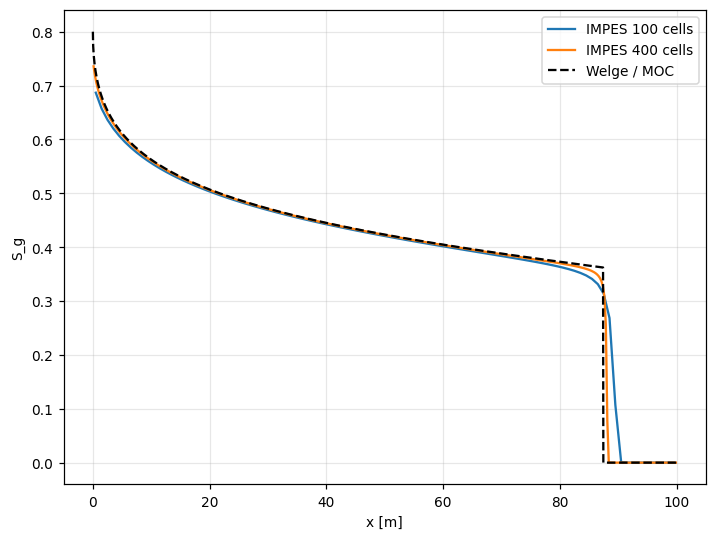

In [3]:
fl = FluidProperties(c_a=0, c_g=0); rp = RelPerm(); rk = RockProperties(c_r=0)
L, A, ph, q = 100., 10., .2, 1e-5; T = .4*L*A*ph/q
for nc in (100, 400):
    g = CartesianGrid1D(n=nc, L=L, area=A)
    mm = TwoPhaseModel([g], np.full((1, nc), md_to_m2(100)), np.full((1, nc), ph), fl, rp, rk,
                       15*MPA, cfl=.3, max_dS=.05, dt_init=100., dt_max=T/50)
    r = mm.run(InjectionSchedule([0, T], [q*fl.rho_g]), np.array([T]))
    plt.plot(g.centres, r.Sg[-1, 0], label=f'IMPES {nc} cells')
x = np.linspace(0, L, 2000)
plt.plot(x, bl_profile_1d(rp, fl, x, T, q, A, ph, L=L), 'k--', label='Welge / MOC')
plt.xlabel('x [m]'); plt.ylabel('S_g'); plt.legend()
print('Welge shock saturation, fractional flow:', welge_shock(rp, fl)[:2])

## 3. The verification report of the last pipeline run

In [4]:
V = json.loads((Path(cfg.paths.metrics)/'validation.json').read_text())
display(pd.Series(V['verdict']).to_frame('pass'))
r7 = V['V6_V7_V8_radial_two_phase']
for key in ('n_r', 'r_near', 'max_dS'):
    print(key); display(pd.DataFrame(r7[key]).T[['dp_bh_max_MPa','r_plume_end_m','n_steps','wall_time_s']])
print('strict vs relaxed time stepping'); display(pd.DataFrame(r7['cfl']).T)

,pass
steady_radial_pressure,True
well_index_bhp,True
closed_tank,True
buckley_leverett_front,True
buckley_leverett_L1,True
bl_no_clipping,True
radial_mass_balance,True
radial_no_clipping,True
radial_saturation_bounds,True
no_odd_even_oscillation,True


n_r


,dp_bh_max_MPa,r_plume_end_m,n_steps,wall_time_s
30,5.625926,1211.286636,14951.0,8.383448
60,5.628555,1095.983706,34147.0,20.646097
120,5.622874,1029.830755,72671.0,45.721428


r_near


,dp_bh_max_MPa,r_plume_end_m,n_steps,wall_time_s
20.0,6.988833,1054.536553,2705.0,1.725045
10.0,6.308278,1066.974012,9208.0,5.392868
5.0,5.628555,1095.983706,34147.0,20.505845


max_dS


,dp_bh_max_MPa,r_plume_end_m,n_steps,wall_time_s
0.1,5.603112,1095.983766,34142.0,20.199278
0.05,5.628555,1095.983706,34147.0,20.499246
0.02,5.638577,1095.983759,34211.0,19.703125


strict vs relaxed time stepping


,dp_bh_max_MPa,r_plume_end_m,mass_retained_Mt,n_steps,wall_time_s,near_well_oscillation,dp_bh_max,r_plume_end,mass_retained
relaxed,5.628555,1095.969782,4.733640,13107.000000,11.154520,9.000000,NaN,NaN,NaN
strict_default,5.628555,1095.983706,4.733640,34147.000000,20.899127,1.000000,NaN,NaN,NaN
rel_diff,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000013,6.849893e-15
step_ratio_strict_over_relaxed,2.605249,2.605249,2.605249,2.605249,2.605249,2.605249,2.605249,2.605249,2.605249e+00


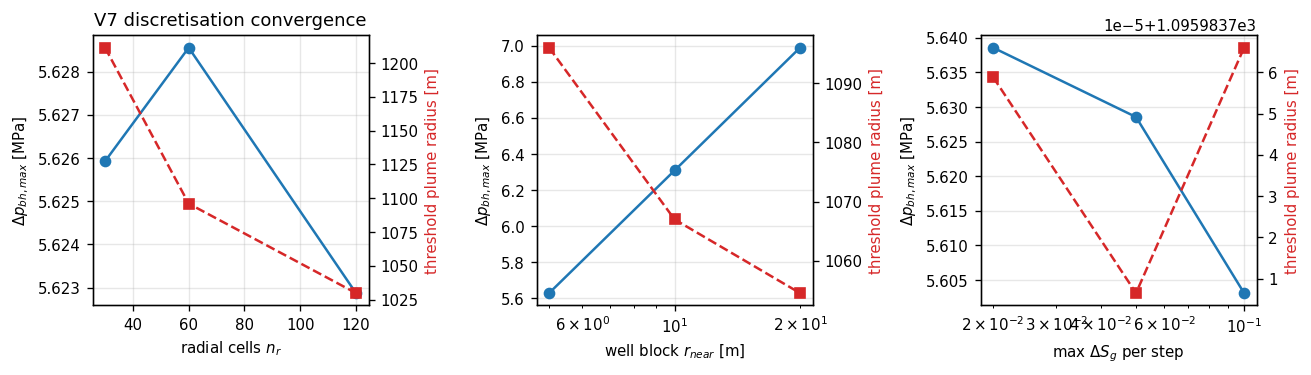

{
 "dp_bh_max": 0.07072233570614324,
 "r_plume_end": -0.39350095656934253,
 "mass_retained": 4.029348731235377e-15,
 "sweep_efficiency": 0.10224247784649756
}


In [5]:
display(Image(str(Path(cfg.paths.figures)/'02_validation_convergence.png')))
print(json.dumps(V['V10_upscaling_two_phase']['relative_error'], indent=1))

V10 answers the question posed on `2-Upscaling.pdf` p.3-4: upscaling the layers into one (thickness-weighted arithmetic k, exact for single-phase parallel flow) keeps the pressure close but loses the layer-by-layer velocity contrast that controls the plume's leading edge.